In [1]:
!pip install yfinance scikit-learn

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
stock = "AAPL"
data = yf.download(stock, start="2020-01-01", end="2024-01-01")


/tmp/ipykernel_205/2958800368.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [5]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928032,72.533072,71.708672,72.277555,108872000
2020-01-08,73.085091,73.386408,71.631537,71.631537,132079200


In [6]:
data['Target']= data['Close'].shift(-1)

In [7]:
data= data.dropna()

In [8]:
X= data[['Open', 'High', 'Low', 'Volume']]
Y= data['Target']

In [9]:
split=int(len(data)*0.8)

X_train = X[:split]
X_test= X[split:]
Y_train= Y[:split]
Y_test= Y[split:]

In [10]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [11]:
predictions = model.predict(X_test)


In [12]:
mse= mean_squared_error(Y_test, predictions)
print("Mean Squared Error", mse)

Mean Squared Error 4.945962675714158


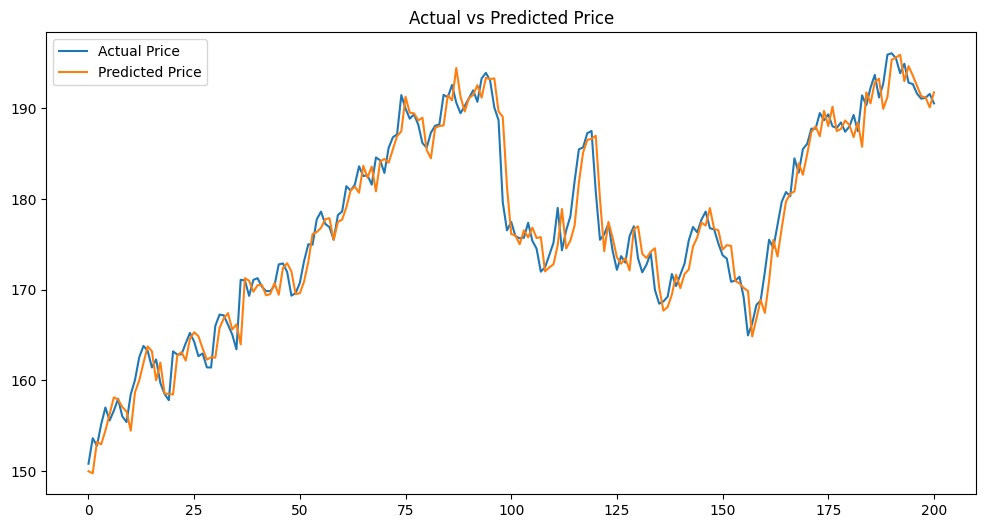

In [13]:
plt.figure(figsize=(12,6))
plt.plot(Y_test.values, label= "Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Price")
plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, Y_train)

rf_predictions = rf.predict(X_test)

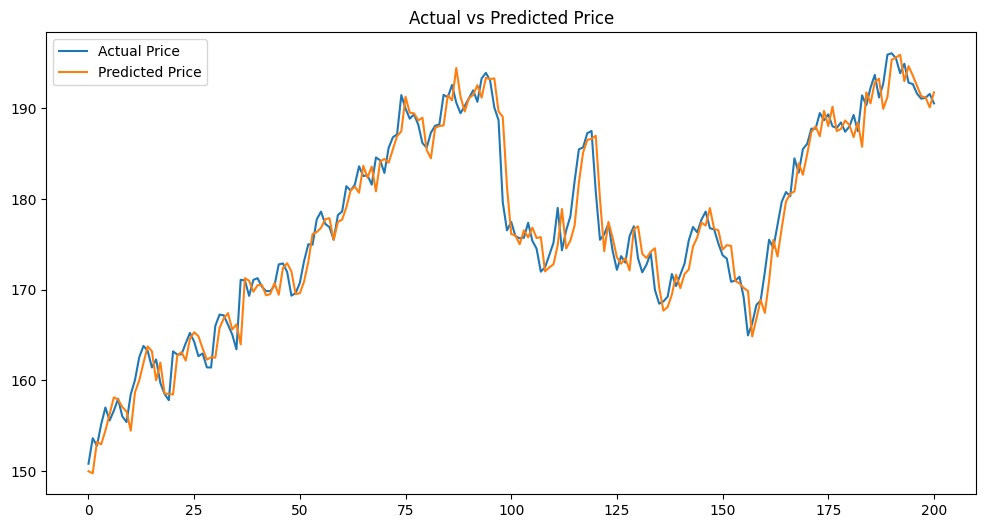

In [16]:
plt.figure(figsize=(12,6))
plt.plot(Y_test.values, label= "Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Price")
plt.show()